<a href="https://colab.research.google.com/github/alfadder/ProgForDataAnalysis/blob/main/Programming_For_Data_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Research Question?**

How do meteorological conditions (e.g., temperature, wind speed, rainfall) and seasonal variations influence the concentrations of key air pollutants (PM2.5, PM10, and O3) across different monitoring stations in Beijing?

This cell imports essential libraries for data manipulation, analysis, and visualization, including pandas, numpy, sklearn, matplotlib, plotly, and seaborn.

# Task 1: Data Selection & Handling

In [5]:
# @title
import pandas as pd
import numpy as np
import os
import sklearn as sk
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
import seaborn as sns

These commands configure global Git user settings (name and email), which are typically used for committing changes to a repository.

In [6]:
! git config --global user.name "alfadder" # replace with your username that you used to create the Github account
! git config --global user.email "alfadder@gmail.com" # and the email id which you have used to create account

This cell defines Python variables for the GitHub username and the repository name. These variables will be used in subsequent Git operations.

In [7]:
username = "alfadder" #replace with your own user name
repo = "ProgForDataAnalysis"  #replace with your required repo

This command clones the specified GitHub repository into your Colab environment, making the repository's files accessible.

In [8]:
! git clone https://@github.com/{username}/{repo}

Cloning into 'ProgForDataAnalysis'...
remote: Enumerating objects: 24, done.
remote: Counting objects: 100% (24/24), done.
remote: Compressing objects: 100% (24/24), done.
remote: Total 24 (delta 10), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (24/24), 3.26 MiB | 5.12 MiB/s, done.
Resolving deltas: 100% (10/10), done.


This command changes the current working directory to the newly cloned repository, allowing direct access to its contents.

In [9]:
%cd {repo}

/content/ProgForDataAnalysis


This command lists the files and directories within the current working directory (the cloned repository), confirming the successful cloning.

In [10]:
%ls

Programming_For_Data_Analysis.ipynb
PRSA_Data_Dingling_20130301-20170228.csv
PRSA_Data_Dongsi_20130301-20170228.csv
PRSA_Data_Gucheng_20130301-20170228.csv
PRSA_Data_Huairou_20130301-20170228.csv


This cell reads multiple city-specific CSV files, combines them into a single pandas DataFrame named `df`, saves the combined data to a new CSV file, and then displays the first few rows of the combined DataFrame.

In [11]:
# @title
import pandas as pd
import glob

city_files = glob.glob("*.csv")
all_cities_data = []

for file_name in city_files:
  city_df = pd.read_csv(file_name)
  all_cities_data.append(city_df)
  print(f"Loaded: {file_name}")

combined_data = pd.concat(all_cities_data, ignore_index=True)
combined_data.to_csv("all_cities_combined.csv", index=False)
print(f"SUCCESS: Combined {len(city_files)} city files into one file with {len(combined_data)} total rows")
print("The combined file is saved as: all_cities_combined.csv")

df= pd.read_csv('all_cities_combined.csv')
df


Loaded: PRSA_Data_Dongsi_20130301-20170228.csv
Loaded: PRSA_Data_Gucheng_20130301-20170228.csv
Loaded: PRSA_Data_Dingling_20130301-20170228.csv
Loaded: PRSA_Data_Huairou_20130301-20170228.csv
SUCCESS: Combined 4 city files into one file with 140256 total rows
The combined file is saved as: all_cities_combined.csv


,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,9.0,9.0,3.0,17.0,300.0,89.0,-0.5,1024.5,-21.4,0.0,NNW,5.7,Dongsi
1,2,2013,3,1,1,4.0,4.0,3.0,16.0,300.0,88.0,-0.7,1025.1,-22.1,0.0,NW,3.9,Dongsi
2,3,2013,3,1,2,7.0,7.0,NaN,17.0,300.0,60.0,-1.2,1025.3,-24.6,0.0,NNW,5.3,Dongsi
3,4,2013,3,1,3,3.0,3.0,5.0,18.0,NaN,NaN,-1.4,1026.2,-25.5,0.0,N,4.9,Dongsi
4,5,2013,3,1,4,3.0,3.0,7.0,NaN,200.0,84.0,-1.9,1027.1,-24.5,0.0,NNW,3.2,Dongsi
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
140251,35060,2017,2,28,19,16.0,28.0,2.0,19.0,300.0,95.0,9.9,1008.6,-14.1,0.0,WNW,1.8,Huairou
140252,35061,2017,2,28,20,21.0,34.0,4.0,24.0,500.0,80.0,9.5,1008.9,-14.4,0.0,SSW,1.3,Huairou
140253,35062,2017,2,28,21,17.0,33.0,2.0,39.0,900.0,60.0,8.4,1009.3,-14.6,0.0,SE,1.5,Huairou
140254,35063,2017,2,28,22,11.0,29.0,3.0,32.0,1400.0,69.0,8.3,1009.5,-14.7,0.0,ENE,3.2,Huairou


# 2.1.Data Understanding

This code calculates and displays the count of unique values in the 'station' column of the `df` DataFrame, showing how many entries exist for each station.

In [12]:
# @title
stations = df['station'].value_counts()
stationdescribe = df['station'].describe()
stationinfo = pd.DataFrame(stations)
stationsdatatype = df['station'].dtypes

print("station data type")
print(stationsdatatype)
print("\nDescription of the 'station' column:")
print(stationinfo)
print("\nData type of the 'station' column:")
print(stationsdatatype)

print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")



station data type
object

Description of the 'station' column:
          count
station        
Dongsi    35064
Gucheng   35064
Dingling  35064
Huairou   35064

Data type of the 'station' column:
object
Number of rows: 140256
Number of columns: 18


### Explanation of 'station' column analysis

The output from 'df['station'].value_counts()', 'df['station'].describe()`, and 'df['station'].dtypes' provides the following insights:

*   Station Counts: There are 4 unique stations (Gucheng, Huairou, Dongsi, Dingling), and each station has 35,064 entries. This means the dataset is balanced across these locations. due to the fact it covers the same period of time and nay missing data has been cprrectly handled and estimated.
*   Data TYpe: The 'station' column is of 'object' data type, which is appropriate for string data.
*   Description: The 'describe()' output confirms the count, number of unique values, and identifies 'Gucheng' as the most frequent station, though all stations appear equally often in terms of row count. This indicates that all selected stations have an equal amount of hourly data.

This confirms the successful merging of data from the four selected stations.

# 2.2.Data preprocessing:

This cell creates a new 'date' column by combining the 'year', 'month', 'day', and 'hour' columns into a single datetime object, which is crucial for time-series analysis.

In [13]:
# @title
import pandas as pd
df['date'] = pd.to_datetime(df[['year', 'month', 'day', 'hour']])
df.head()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station,date
0,1,2013,3,1,0,9.0,9.0,3.0,17.0,300.0,89.0,-0.5,1024.5,-21.4,0.0,NNW,5.7,Dongsi,2013-03-01 00:00:00
1,2,2013,3,1,1,4.0,4.0,3.0,16.0,300.0,88.0,-0.7,1025.1,-22.1,0.0,NW,3.9,Dongsi,2013-03-01 01:00:00
2,3,2013,3,1,2,7.0,7.0,NaN,17.0,300.0,60.0,-1.2,1025.3,-24.6,0.0,NNW,5.3,Dongsi,2013-03-01 02:00:00
3,4,2013,3,1,3,3.0,3.0,5.0,18.0,NaN,NaN,-1.4,1026.2,-25.5,0.0,N,4.9,Dongsi,2013-03-01 03:00:00
4,5,2013,3,1,4,3.0,3.0,7.0,NaN,200.0,84.0,-1.9,1027.1,-24.5,0.0,NNW,3.2,Dongsi,2013-03-01 04:00:00


This cell generates a heatmap to visually represent missing values across the DataFrame before any imputation, providing an overview of data completeness. It also shows descriptive statistics for all numerical columns.

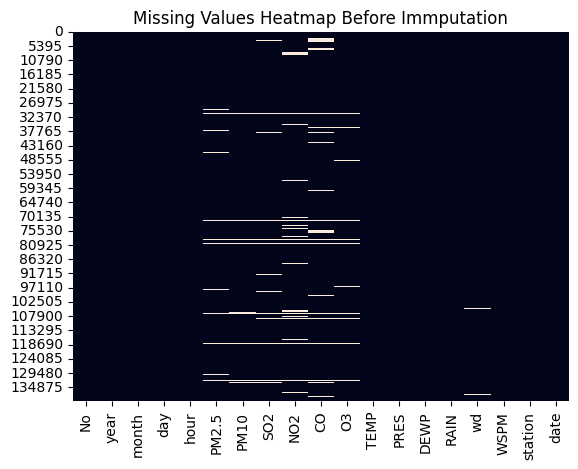

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,WSPM,date
count,140256.000,140256.000000,140256.000000,140256.000000,140256.000000,137128.000000,137889.000000,137376.000000,135114.000000,132224.000000,136498.000000,140081.00000,140083.000000,140079.000000,140087.000000,140108.000000,140256
mean,17532.500,2014.662560,6.522930,15.729637,11.500000,76.433458,101.156036,14.449835,42.468751,1143.995561,60.793546,13.41694,1009.184718,2.200587,0.064194,1.677524,2015-03-01 11:29:59.999999744
min,1.000,2013.000000,1.000000,1.000000,0.000000,2.000000,2.000000,0.285600,1.026500,100.000000,0.214200,-19.90000,982.400000,-43.400000,0.000000,0.000000,2013-03-01 00:00:00
25%,8766.750,2014.000000,4.000000,8.000000,5.750000,19.000000,33.000000,2.000000,16.000000,400.000000,17.000000,3.00000,1000.800000,-9.400000,0.000000,0.900000,2014-03-01 05:45:00
50%,17532.500,2015.000000,7.000000,16.000000,11.500000,52.000000,78.000000,6.000000,34.000000,800.000000,51.000000,14.40000,1008.800000,2.600000,0.000000,1.300000,2015-03-01 11:30:00
75%,26298.250,2016.000000,10.000000,23.000000,17.250000,107.000000,143.000000,18.000000,61.134550,1400.000000,85.000000,23.10000,1017.300000,15.000000,0.000000,2.100000,2016-02-29 17:15:00
max,35064.000,2017.000000,12.000000,31.000000,23.000000,881.000000,994.000000,500.000000,276.000000,10000.000000,1071.000000,41.60000,1042.000000,29.100000,52.100000,12.900000,2017-02-28 23:00:00
std,10122.141,1.177201,3.448715,8.800123,6.922211,78.994830,90.945361,20.020561,33.603041,1076.211778,56.080125,11.48208,10.349554,13.873769,0.807661,1.254475,NaN


In [14]:
# @title
sns.heatmap(df.isnull(), cbar=False)
plt.title('Missing Values Heatmap Before Immputation')
plt.show()
df.describe()

This code identifies all numerical columns in the DataFrame that contain missing values, which are the target columns for the subsequent imputation steps.

In [15]:
# @title
numerical_df = df.select_dtypes(include=np.number)
missing_values_count = numerical_df.isnull().sum()
numerical_cols_with_missing_values = missing_values_count[missing_values_count > 0].index.tolist()

print("Numerical columns with missing values:")
print(numerical_cols_with_missing_values)

Numerical columns with missing values:
['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3', 'TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM']


This cell performs a two-step grouped mean imputation for numerical columns. It first fills missing values by grouping by 'station', 'year', and 'month', and then specifically imputes any remaining 'CO' missing values by grouping by 'station' and 'month'.

In [16]:
# @title
for col in numerical_cols_with_missing_values:
    df[col] = df.groupby(['station', df['date'].dt.year, df['date'].dt.month])[col].transform(lambda x: x.fillna(x.mean()))

# Impute remaining 'CO' values by station and month for cases where entire months were missing
if 'CO' in numerical_cols_with_missing_values and df['CO'].isnull().any():
    df['CO'] = df.groupby(['station', df['date'].dt.month])['CO'].transform(lambda x: x.fillna(x.mean()))

print("Missing values after grouped mean imputation:")
print(df[numerical_cols_with_missing_values].isnull().sum())

Missing values after grouped mean imputation:
PM2.5    0
PM10     0
SO2      0
NO2      0
CO       0
O3       0
TEMP     0
PRES     0
DEWP     0
RAIN     0
WSPM     0
dtype: int64


This code prints a summary of all remaining missing values across the entire DataFrame after the numerical imputation steps, highlighting columns that still have nulls (e.g., 'wd').

In [17]:
# @title
print("Remaining missing values after grouped mean imputation:")
print(df.isnull().sum())

Remaining missing values after grouped mean imputation:
No           0
year         0
month        0
day          0
hour         0
PM2.5        0
PM10         0
SO2          0
NO2          0
CO           0
O3           0
TEMP         0
PRES         0
DEWP         0
RAIN         0
wd         679
WSPM         0
station      0
date         0
dtype: int64


This cell displays the complete `df` DataFrame after the numerical imputation, allowing you to view the current state of the data.

In [18]:
df

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station,date
0,1,2013,3,1,0,9.0,9.0,3.000000,17.000000,300.000000,89.000000,-0.5,1024.5,-21.4,0.0,NNW,5.7,Dongsi,2013-03-01 00:00:00
1,2,2013,3,1,1,4.0,4.0,3.000000,16.000000,300.000000,88.000000,-0.7,1025.1,-22.1,0.0,NW,3.9,Dongsi,2013-03-01 01:00:00
2,3,2013,3,1,2,7.0,7.0,39.831952,17.000000,300.000000,60.000000,-1.2,1025.3,-24.6,0.0,NNW,5.3,Dongsi,2013-03-01 02:00:00
3,4,2013,3,1,3,3.0,3.0,5.000000,18.000000,1529.192616,59.489526,-1.4,1026.2,-25.5,0.0,N,4.9,Dongsi,2013-03-01 03:00:00
4,5,2013,3,1,4,3.0,3.0,7.000000,76.904376,200.000000,84.000000,-1.9,1027.1,-24.5,0.0,NNW,3.2,Dongsi,2013-03-01 04:00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
140251,35060,2017,2,28,19,16.0,28.0,2.000000,19.000000,300.000000,95.000000,9.9,1008.6,-14.1,0.0,WNW,1.8,Huairou,2017-02-28 19:00:00
140252,35061,2017,2,28,20,21.0,34.0,4.000000,24.000000,500.000000,80.000000,9.5,1008.9,-14.4,0.0,SSW,1.3,Huairou,2017-02-28 20:00:00
140253,35062,2017,2,28,21,17.0,33.0,2.000000,39.000000,900.000000,60.000000,8.4,1009.3,-14.6,0.0,SE,1.5,Huairou,2017-02-28 21:00:00
140254,35063,2017,2,28,22,11.0,29.0,3.000000,32.000000,1400.000000,69.000000,8.3,1009.5,-14.7,0.0,ENE,3.2,Huairou,2017-02-28 22:00:00


This cell defines a list of column names (`gas_columns`) that represent various gas measurements, preparing for specific operations on these columns.

In [19]:
# @title
gas_columns = ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3']
print("Identified gas columns:")
print(gas_columns)

Identified gas columns:
['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3']


This code selects the defined `gas_columns`, rounds their values to one decimal place, and displays the resulting formatted DataFrame, providing a clean view of the gas measurement data.

In [20]:
# @title
formatted_gas_data = df[gas_columns].round(1)
print("Formatted gas measurement columns (rounded to 1 decimal place):")
formatted_gas_data

Formatted gas measurement columns (rounded to 1 decimal place):


,PM2.5,PM10,SO2,NO2,CO,O3
0,9.0,9.0,3.0,17.0,300.0,89.0
1,4.0,4.0,3.0,16.0,300.0,88.0
2,7.0,7.0,39.8,17.0,300.0,60.0
3,3.0,3.0,5.0,18.0,1529.2,59.5
4,3.0,3.0,7.0,76.9,200.0,84.0
...,...,...,...,...,...,...
140251,16.0,28.0,2.0,19.0,300.0,95.0
140252,21.0,34.0,4.0,24.0,500.0,80.0
140253,17.0,33.0,2.0,39.0,900.0,60.0
140254,11.0,29.0,3.0,32.0,1400.0,69.0


This cell performs a two-step grouped mode imputation for the categorical 'wd' column. It first fills missing values by grouping by 'station', 'year', and 'month', and then by 'station' and 'month' for any remaining nulls, ensuring 'wd' is fully imputed.

In [21]:
# @title
print("Missing values in 'wd' before imputation:")
print(df['wd'].isnull().sum())

# Impute missing values in 'wd' by grouping by 'station', 'year', 'month' using the mode
df['wd'] = df.groupby(['station', df['date'].dt.year, df['date'].dt.month])['wd'].transform(lambda x: x.fillna(x.mode()[0] if not x.mode().empty else np.nan))

# Impute remaining missing values in 'wd' by grouping by 'station', 'month' using the mode
df['wd'] = df.groupby(['station', df['date'].dt.month])['wd'].transform(lambda x: x.fillna(x.mode()[0] if not x.mode().empty else np.nan))

print("\nMissing values in 'wd' after grouped mode imputation:")
print(df['wd'].isnull().sum())

print("\nRemaining missing values in the entire DataFrame:")
print(df.isnull().sum())

Missing values in 'wd' before imputation:
679

Missing values in 'wd' after grouped mode imputation:
0

Remaining missing values in the entire DataFrame:
No         0
year       0
month      0
day        0
hour       0
PM2.5      0
PM10       0
SO2        0
NO2        0
CO         0
O3         0
TEMP       0
PRES       0
DEWP       0
RAIN       0
wd         0
WSPM       0
station    0
date       0
dtype: int64


Removing Duplicates in the dataframe - there are no duplicates in this dataset

In [22]:
df.duplicated().sum()

np.int64(0)

Featured Engineering

In [23]:
# @title
# Extract day of the week (Monday=0, Sunday=6)
df['day_of_week'] = df['date'].dt.dayofweek

# Create a binary flag for weekend (Saturday=5, Sunday=6)
df['is_weekend'] = df['day_of_week'].isin([5, 6]).astype(int)

print("New temporal features added to DataFrame (first 5 rows):")
display(df[['date', 'day_of_week', 'is_weekend']].head())


New temporal features added to DataFrame (first 5 rows):


,date,day_of_week,is_weekend
0,2013-03-01 00:00:00,4,0
1,2013-03-01 01:00:00,4,0
2,2013-03-01 02:00:00,4,0
3,2013-03-01 03:00:00,4,0
4,2013-03-01 04:00:00,4,0


# 2.3.Statistical/Computational Analysis & Visualisation

This cell displays a heatmap of missing values for the final DataFrame, which should be entirely blank if all imputations were successful. It also provides descriptive statistics for the fully imputed dataset.

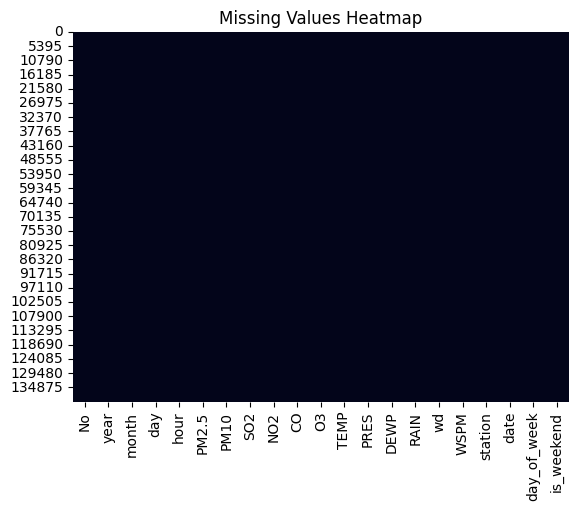

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,WSPM,date,day_of_week,is_weekend
count,140256.000,140256.000000,140256.000000,140256.000000,140256.000000,140256.000000,140256.000000,140256.000000,140256.000000,140256.000000,140256.000000,140256.000000,140256.000000,140256.000000,140256.000000,140256.000000,140256,140256.000000,140256.000000
mean,17532.500,2014.662560,6.522930,15.729637,11.500000,76.418775,101.142820,14.447132,42.427050,1149.245679,61.039722,13.405744,1009.191585,2.187762,0.064145,1.677643,2015-03-01 11:29:59.999999744,3.000684,0.286105
min,1.000,2013.000000,1.000000,1.000000,0.000000,2.000000,2.000000,0.285600,1.026500,100.000000,0.214200,-19.900000,982.400000,-43.400000,0.000000,0.000000,2013-03-01 00:00:00,0.000000,0.000000
25%,8766.750,2014.000000,4.000000,8.000000,5.750000,19.000000,33.000000,2.000000,16.000000,500.000000,17.000000,3.000000,1000.800000,-9.400000,0.000000,0.900000,2014-03-01 05:45:00,1.000000,0.000000
50%,17532.500,2015.000000,7.000000,16.000000,11.500000,53.000000,79.000000,6.000000,34.000000,900.000000,51.000000,14.400000,1008.900000,2.600000,0.000000,1.300000,2015-03-01 11:30:00,3.000000,0.000000
75%,26298.250,2016.000000,10.000000,23.000000,17.250000,106.000000,142.000000,18.000000,61.000000,1400.000000,86.000000,23.100000,1017.300000,14.900000,0.000000,2.100000,2016-02-29 17:15:00,5.000000,1.000000
max,35064.000,2017.000000,12.000000,31.000000,23.000000,881.000000,994.000000,500.000000,276.000000,10000.000000,1071.000000,41.600000,1042.000000,29.100000,52.100000,12.900000,2017-02-28 23:00:00,6.000000,1.000000
std,10122.141,1.177201,3.448715,8.800123,6.922211,78.212436,90.272532,19.902119,33.148722,1052.332571,55.560721,11.483923,10.347359,13.875769,0.807177,1.253877,NaN,2.001204,0.451941


In [24]:
# @title
sns.heatmap(df.isnull(), cbar=False)
plt.title('Missing Values Heatmap')
plt.show()
df.describe()

### Feature Engineering: Simplified Air Quality Index (AQI) & Analysis

To provide a more comprehensive view of air quality, we calculate a simplified Air Quality Index (AQI) primarily based on **PM2.5** concentrations, using common breakpoints. This allows for a single, more intuitive metric. The function `calculate_simplified_aqi_pm25` maps PM2.5 values to qualitative AQI categories (`'Good'`, `'Moderate'`, `'Unhealthy for Sensitive Groups'`, `'Unhealthy'`, `'Very Unhealthy'`, `'Hazardous'`).

After creating the `AQI_PM25_Category` column, we then analyze its distribution across different days of the week. This involves calculating the proportion of each AQI category for every day and visualizing it using a stacked bar chart. This helps in identifying weekly patterns or trends in overall air quality.

In [25]:
# @title
def calculate_simplified_aqi_pm25(pm25):
    if pm25 <= 12.0:
        return 'Good'
    elif pm25 <= 35.4:
        return 'Moderate'
    elif pm25 <= 55.4:
        return 'Unhealthy for Sensitive Groups'
    elif pm25 <= 150.4:
        return 'Unhealthy'
    elif pm25 <= 250.4:
        return 'Very Unhealthy'
    else:
        return 'Hazardous'


df['AQI_PM25_Category'] = df['PM2.5'].apply(calculate_simplified_aqi_pm25)

df['month_start_date'] = df['date'].dt.to_period('M').dt.to_timestamp()

monthly_aqi_proportions = df.groupby(['station', 'month_start_date', 'AQI_PM25_Category']).size().unstack(fill_value=0)
monthly_aqi_proportions = monthly_aqi_proportions.apply(lambda x: x / x.sum(), axis=1)

aqi_order = ['Good', 'Moderate', 'Unhealthy for Sensitive Groups', 'Unhealthy', 'Very Unhealthy', 'Hazardous']
for col in aqi_order:
    if col not in monthly_aqi_proportions.columns:
        monthly_aqi_proportions[col] = 0
monthly_aqi_proportions = monthly_aqi_proportions[aqi_order]

monthly_aqi_proportions = monthly_aqi_proportions.reset_index()
print("Monthly AQI proportions by station:")
display(monthly_aqi_proportions.head())

Monthly AQI proportions by station:


AQI_PM25_Category,station,month_start_date,Good,Moderate,Unhealthy for Sensitive Groups,Unhealthy,Very Unhealthy,Hazardous
0,Dingling,2013-03-01,0.205645,0.125000,0.114247,0.315860,0.161290,0.077957
1,Dingling,2013-04-01,0.302778,0.165278,0.143056,0.311111,0.075000,0.002778
2,Dingling,2013-05-01,0.107527,0.176075,0.159946,0.465054,0.071237,0.020161
3,Dingling,2013-06-01,0.061111,0.256944,0.118056,0.418056,0.111111,0.034722
4,Dingling,2013-07-01,0.134409,0.348118,0.165323,0.295699,0.056452,0.000000


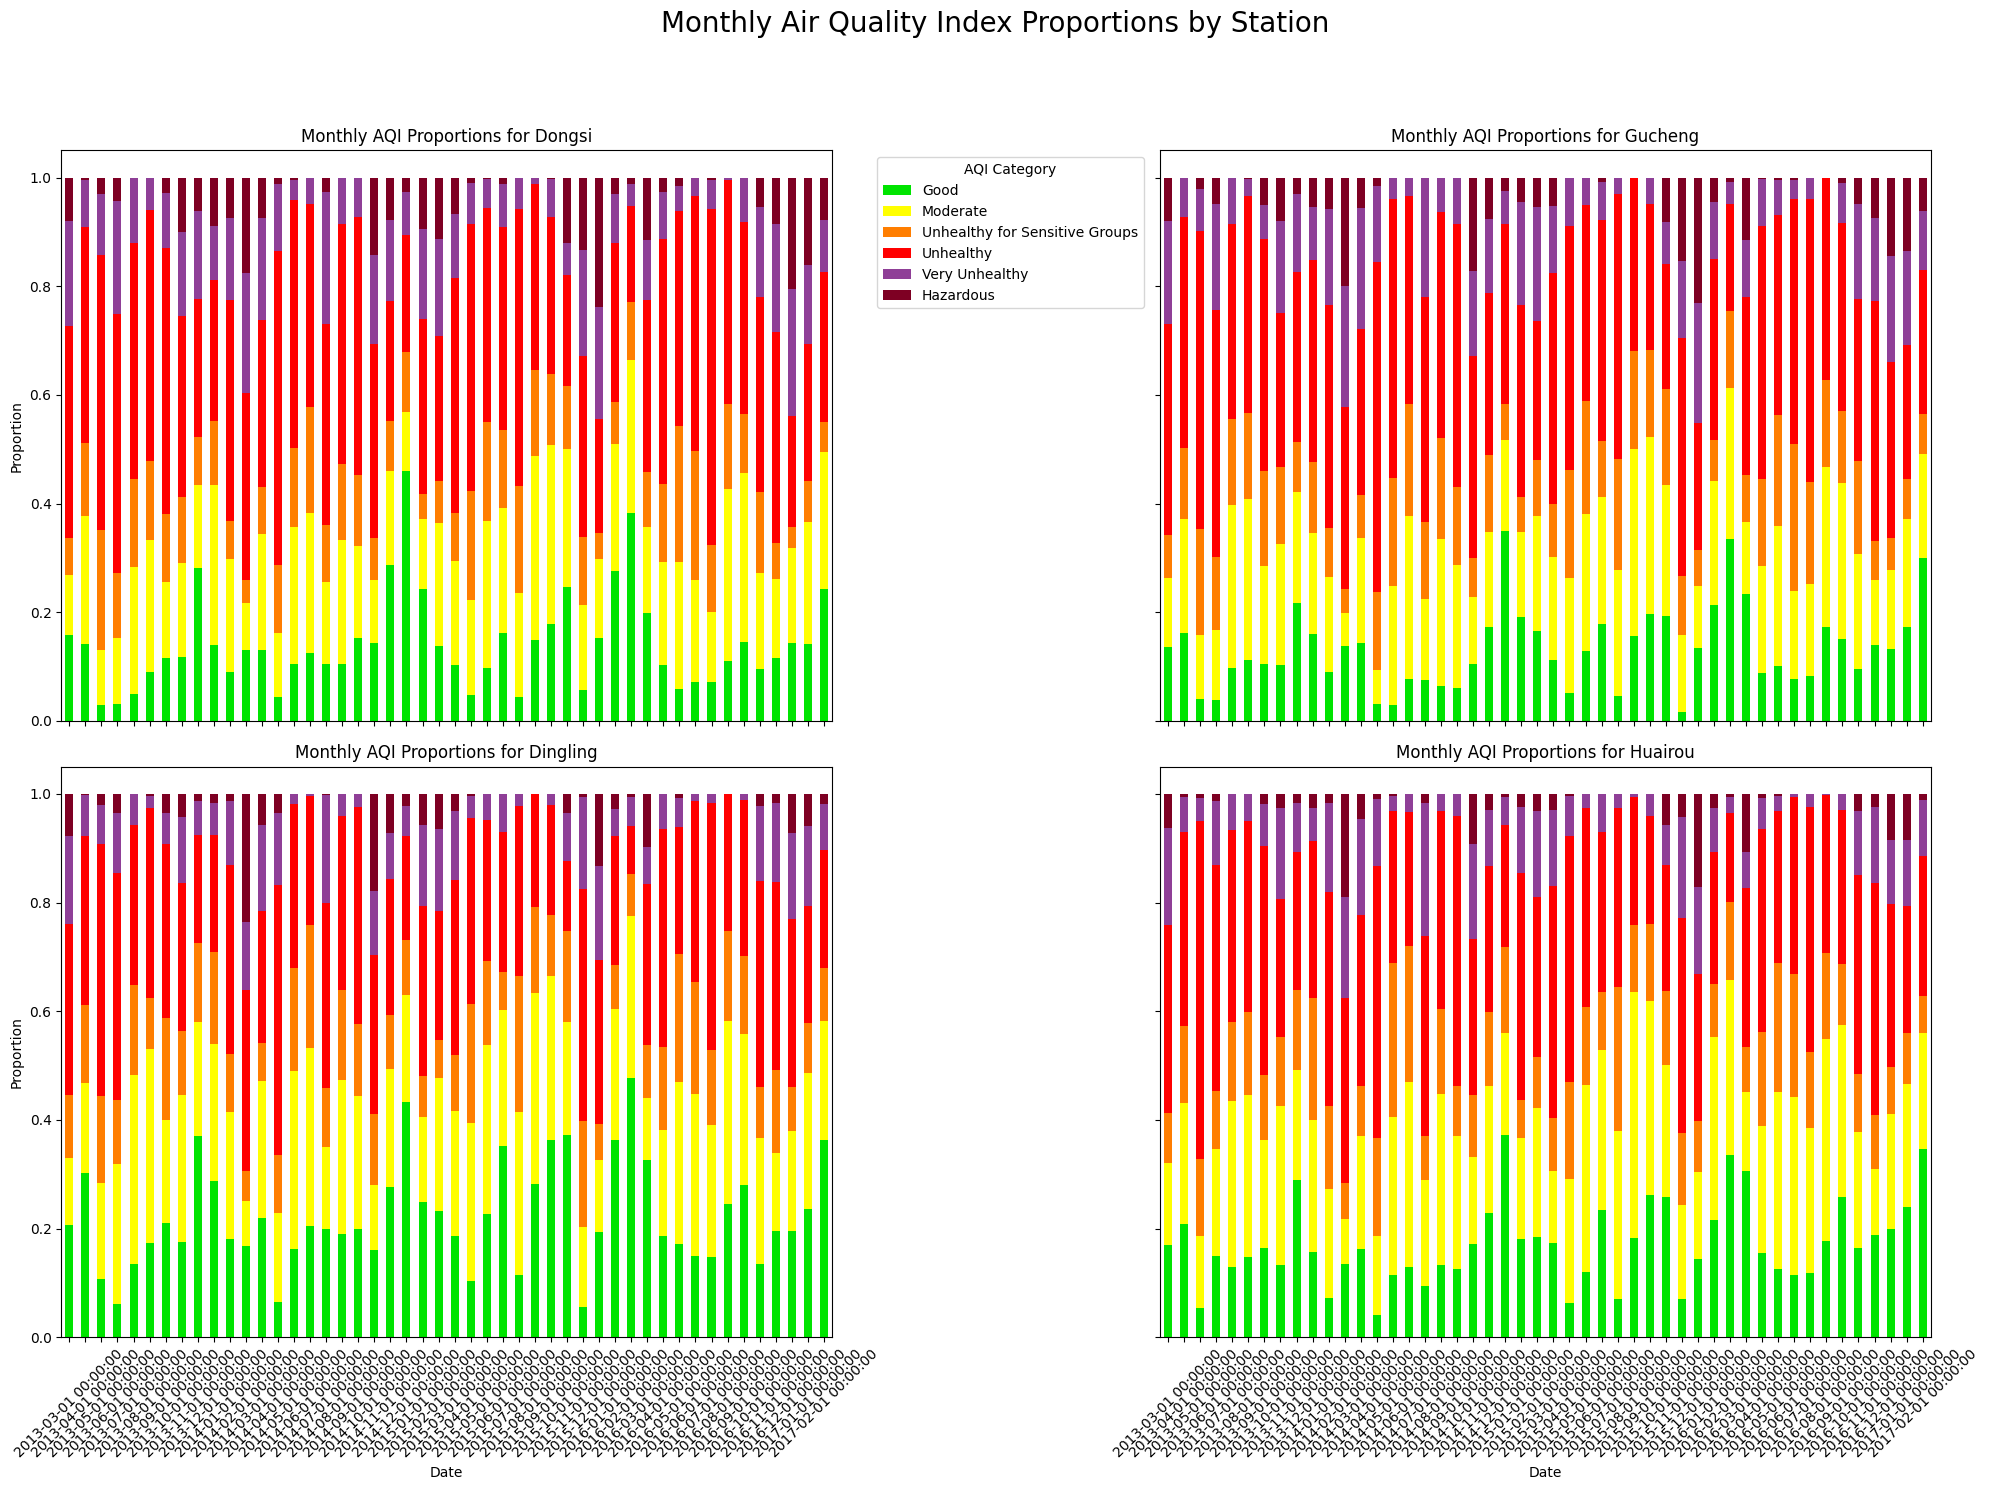

In [26]:
# @title
import matplotlib.pyplot as plt
import seaborn as sns

aqi_colors = {
    'Good': '#00e400',  # Green
    'Moderate': '#ffff00', # Yellow
    'Unhealthy for Sensitive Groups': '#ff7e00', # Orange
    'Unhealthy': '#ff0000', # Red
    'Very Unhealthy': '#8f3f97', # Purple
    'Hazardous': '#7e0023'  # reddy-purpley
}

stations_list = df['station'].unique()
fig, axes = plt.subplots(2, 2, figsize=(20, 15), sharex=True, sharey=True)
axes = axes.flatten()

for i, station in enumerate(stations_list):
    station_data = monthly_aqi_proportions[monthly_aqi_proportions['station'] == station]
    station_data_pivot = station_data.set_index('month_start_date')[aqi_order]

    station_data_pivot.plot(kind='bar', stacked=True, ax=axes[i], color=[aqi_colors[cat] for cat in aqi_order])
    axes[i].set_title(f'Monthly AQI Proportions for {station}')
    axes[i].set_xlabel('Date')
    axes[i].set_ylabel('Proportion')
    axes[i].tick_params(axis='x', rotation=45)

    if i == 0:
        axes[i].legend(title='AQI Category', bbox_to_anchor=(1.05, 1), loc='upper left')
    else:
        axes[i].get_legend().remove()

plt.suptitle('Monthly Air Quality Index Proportions by Station', fontsize=20, y=1.02)
plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()


these visualizations show the monthly proportions of different Air Quality Index categories (Good, Moderate, Unhealthy for Sensitive Groups, Unhealthy, Very Unhealthy, Hazardous) for each of the four stations (Dingling, Dongsi, Huairou, Gucheng) over time. They allow us to observe how the air quality composition changes month-to-month and to compare the overall air quality trends across different stations. For example, you can see periods where a station had a higher proportion of 'Good' air quality days versus 'Unhealthy' or 'Hazardous' days, and how these proportions shift seasonally or annually. the difference in these station could be put down to the fact that each of these stations have different levels of urbanisation.

# Section 2.3

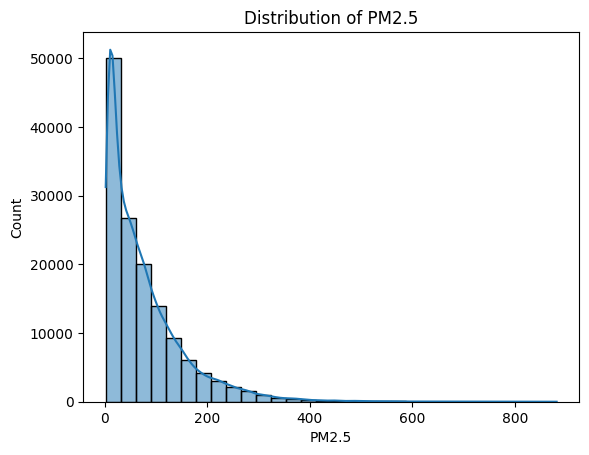

In [27]:
# @title
import seaborn as sns
sns.histplot(data=df, x="PM2.5", bins=30, kde=True)
title = "Distribution of PM2.5"
plt.title(title)
plt.show()

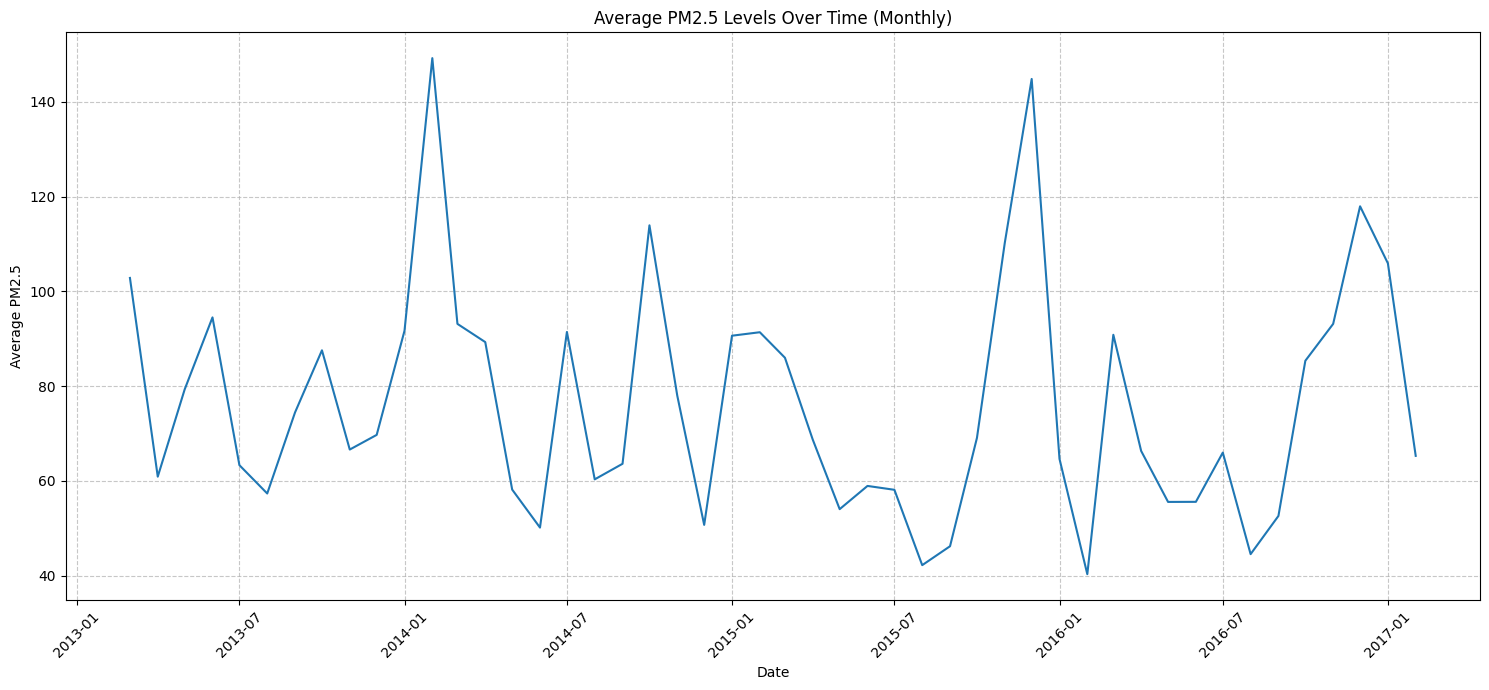

In [28]:
# @title
import matplotlib.pyplot as plt
import seaborn as sns

# Group by this new monthly date and calculate the mean PM2.5
monthly_pm25_over_time = df.groupby('month_start_date')['PM2.5'].mean().reset_index()

plt.figure(figsize=(15, 7))
sns.lineplot(x='month_start_date', y='PM2.5', data=monthly_pm25_over_time)
plt.title('Average PM2.5 Levels Over Time (Monthly)')
plt.xlabel('Date')
plt.ylabel('Average PM2.5')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [29]:
# @title
monthly_avg_gas_levels = df.groupby(['station', 'month_start_date'])[gas_columns].mean().reset_index()
print("Monthly Average Gas Levels by Station:")
monthly_avg_gas_levels.head()

Monthly Average Gas Levels by Station:


,station,month_start_date,PM2.5,PM10,SO2,NO2,CO,O3
0,Dingling,2013-03-01,95.705645,110.311231,24.358088,48.238364,1015.409859,68.141251
1,Dingling,2013-04-01,55.206506,80.148936,13.725471,26.967120,635.846726,73.853376
2,Dingling,2013-05-01,71.402266,114.093220,17.413140,28.586733,766.922619,97.733500
3,Dingling,2013-06-01,85.520950,87.280112,7.829724,20.992806,1145.575403,81.439421
4,Dingling,2013-07-01,54.012676,56.859773,4.191483,15.649809,759.668666,81.595652


In [30]:
# @title
from plotly.subplots import make_subplots
import plotly.graph_objects as go
import plotly.express as px

num_gas_types = len(gas_columns)
num_rows = 3
num_cols = 2

# Create subplots
fig = make_subplots(rows=num_rows, cols=num_cols,
                    subplot_titles=[f'Monthly Average {gas} Levels' for gas in gas_columns])

# Define a consistent color map for stations
stations_list = monthly_avg_gas_levels['station'].unique()
colors = px.colors.qualitative.Plotly # Or choose another palette like 'Dark2', 'Set1', etc.
station_color_map = {station: colors[idx % len(colors)] for idx, station in enumerate(stations_list)}

# Add traces for each gas type and station to the subplots
for i, gas_type in enumerate(gas_columns):
    row = (i // num_cols) + 1
    col = (i % num_cols) + 1

    for station in monthly_avg_gas_levels['station'].unique():
        station_data = monthly_avg_gas_levels[monthly_avg_gas_levels['station'] == station]
        fig.add_trace(
            go.Scatter(
                x=station_data['month_start_date'],
                y=station_data[gas_type],
                mode='lines',
                name=station, # Legend will show station names
                legendgroup=station, # Group legends by station
                showlegend=True if i == 0 else False, # Show legend only for the first subplot
                line=dict(color=station_color_map[station]) # Explicitly set color
            ),
            row=row, col=col
        )

    # Update y-axis label for each subplot
    fig.update_yaxes(title_text=f'Average {gas_type} Level', row=row, col=col)

# Update overall layout
fig.update_layout(
    height=1200, width=1400,
    title_text='Monthly Average Gas Levels Over Time by Station (Grid View)',
    hovermode='x unified'
)

# Show the figure
fig.show()

### Distributions of Air Pollutants (Histograms)

This section visualizes the distribution of various air pollutants (PM10, SO2, NO2, CO, O3) using histograms. These plots help to understand the frequency of different concentration levels for each pollutant, revealing typical ranges, skewness, and potential outliers. A `kde` (Kernel Density Estimate) line is overlaid to show the smoothed distribution.

In [ ]:
# @title
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

df = pd.read_csv('all_cities_combined.csv')

# Create the 'date' column (as done in cell 07207d93)
df['date'] = pd.to_datetime(df[['year', 'month', 'day', 'hour']])

# Identify numerical columns with missing values for imputation (as done in cell 666edbb2)
numerical_df = df.select_dtypes(include=np.number)
missing_values_count = numerical_df.isnull().sum()
numerical_cols_with_missing_values = missing_values_count[missing_values_count > 0].index.tolist()

# Perform grouped mean imputation for numerical columns (as done in cell fda92f42)
for col in numerical_cols_with_missing_values:
    df[col] = df.groupby(['station', df['date'].dt.year, df['date'].dt.month])[col].transform(lambda x: x.fillna(x.mean()))

# Impute remaining 'CO' values by station and month (as done in cell fda92f42)
if 'CO' in numerical_cols_with_missing_values and df['CO'].isnull().any():
    df['CO'] = df.groupby(['station', df['date'].dt.month])['CO'].transform(lambda x: x.fillna(x.mean()))

# --- End: Code to ensure 'df' is defined and preprocessed for plotting ---


gas_columns_to_plot = ['PM10', 'SO2', 'NO2', 'CO', 'O3']

# Determine grid dimensions (3 rows, 2 columns for 5 gas types)
num_rows = 3
num_cols = 2

fig, axes = plt.subplots(num_rows, num_cols, figsize=(18, 15))
axes = axes.flatten() # Flatten the 2D array of axes for easy iteration

for i, gas_type in enumerate(gas_columns_to_plot):
    sns.histplot(data=df, x=gas_type, bins=50, kde=True, ax=axes[i], color='skyblue')
    axes[i].set_title(f'Distribution of {gas_type}')
    axes[i].set_xlabel(f'{gas_type} Concentration')
    axes[i].set_ylabel('Frequency')
    axes[i].grid(True, linestyle='--', alpha=0.6)

# Hide any unused subplots
for j in range(len(gas_columns_to_plot), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Histograms of Air Pollutant Distributions', fontsize=20, y=1.02)
plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Adjust layout to prevent title overlap
plt.show()

### Distributions of Meteorological Variables (Density Plots)

This section visualizes the distribution of various meteorological variables (Wind speed, Rainfall, Temperature, Dew Point, and Pressure) using density plots. These plots help to understand the overall shape, spread, and central tendency of these distributions, which can be crucial for understanding their impact on air quality.

In [ ]:
# @title
monthly_avg_rain = df.groupby(df['date'].dt.month)['RAIN'].mean().reset_index()
monthly_avg_rain.rename(columns={'date': 'month'}, inplace=True)

# Find the month with the most rain
max_rain_month_data = monthly_avg_rain.loc[monthly_avg_rain['RAIN'].idxmax()]
max_rain_month = int(max_rain_month_data['month'])
max_rain_value = max_rain_month_data['RAIN']

import calendar
month_name = calendar.month_name[max_rain_month]

print(f"The month with the most average rain is {month_name} with an average of {max_rain_value:.2f} mm.")

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.barplot(x='month', y='RAIN', data=monthly_avg_rain, palette='viridis')
plt.title('Average Monthly Rainfall')
plt.xlabel('Month')
plt.ylabel('Average Rainfall (mm)')
plt.xticks(ticks=range(0,12), labels=[calendar.month_abbr[i] for i in range(1,13)])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
# @title
import matplotlib.pyplot as plt
import seaborn as sns

meteorological_columns_to_plot = ['WSPM', 'RAIN', 'TEMP', 'DEWP', 'PRES']

# Determine grid dimensions (3 rows, 2 columns for 5 variables)
num_rows = 3
num_cols = 2

fig, axes = plt.subplots(num_rows, num_cols, figsize=(18, 15))
axes = axes.flatten() # Flatten the 2D array of axes for easy iteration

for i, var_type in enumerate(meteorological_columns_to_plot):
    sns.kdeplot(data=df, x=var_type, fill=True, ax=axes[i], color='teal')
    axes[i].set_title(f'Density Plot of {var_type}')
    axes[i].set_xlabel(f'{var_type} Value')
    axes[i].set_ylabel('Density')
    axes[i].grid(True, linestyle='--', alpha=0.6)

# Hide any unused subplots
for j in range(len(meteorological_columns_to_plot), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Density Plots of Meteorological Variable Distributions', fontsize=20, y=1.02)
plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Adjust layout to prevent title overlap
plt.show()

Pollutant vs. Temperature (TEMP):

PM2.5 vs. TEMP
PM10 vs. TEMP
O3 vs. TEMP
Insight: Temperature inversions can trap pollutants, while higher temperatures can influence ozone formation.
Pollutant vs. Wind Speed (WSPM):

PM2.5 vs. WSPM
PM10 vs. WSPM
O3 vs. WSPM
Insight: Higher wind speeds generally disperse pollutants, leading to lower concentrations.
Pollutant vs. Rainfall (RAIN):

PM2.5 vs. RAIN
PM10 vs. RAIN
O3 vs. RAIN
Insight: Rainfall can wash pollutants out of the atmosphere, reducing concentrations.
Pollutant vs. Dew Point (DEWP):

PM2.5 vs. DEWP
PM10 vs. DEWP
Insight: High dew points (humidity) can contribute to the formation of secondary aerosols and affect visibility.
Pollutant vs. Pressure (PRES):

PM2.5 vs. PRES
PM10 vs. PRES
Insight: High-pressure systems are often associated with stagnant air masses, leading to pollutant accumulation.

In [ ]:
# @title
import matplotlib.pyplot as plt
import seaborn as sns

pollutant_columns = ['PM2.5', 'PM10', 'O3']

# Determine grid dimensions (2 rows, 2 columns for 3 plots)
num_rows = 2
num_cols = 2

fig, axes = plt.subplots(num_rows, num_cols, figsize=(18, 15))
axes = axes.flatten() # Flatten the 2D array of axes for easy iteration

for i, pollutant in enumerate(pollutant_columns):
    sns.scatterplot(x='TEMP', y=pollutant, data=df, alpha=0.6, hue='station', palette='viridis', s=10, ax=axes[i])
    axes[i].set_title(f'{pollutant} Concentration vs. Temperature')
    axes[i].set_xlabel('Temperature (TEMP)')
    axes[i].set_ylabel(f'{pollutant} Concentration')
    axes[i].grid(True, linestyle='--', alpha=0.7)

# Hide any unused subplots (in this case, the 4th subplot)
for j in range(len(pollutant_columns), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Pollutant Concentrations vs. Temperature by Station', fontsize=20, y=1.02)
plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Adjust layout to prevent title overlap
plt.show()

In [ ]:
# @title
import matplotlib.pyplot as plt
import seaborn as sns

pollutant_columns = ['PM2.5', 'PM10', 'O3']

# Determine grid dimensions (2 rows, 2 columns for 3 plots)
num_rows = 2
num_cols = 2

fig, axes = plt.subplots(num_rows, num_cols, figsize=(18, 15))
axes = axes.flatten() # Flatten the 2D array of axes for easy iteration

for i, pollutant in enumerate(pollutant_columns):
    sns.scatterplot(x='WSPM', y=pollutant, data=df, alpha=0.6, hue='station', palette='viridis', s=10, ax=axes[i])
    axes[i].set_title(f'{pollutant} Concentration vs. Wind Speed (WSPM)')
    axes[i].set_xlabel('Wind Speed (WSPM)')
    axes[i].set_ylabel(f'{pollutant} Concentration')
    axes[i].grid(True, linestyle='--', alpha=0.7)

# Hide any unused subplots (in this case, the 4th subplot)
for j in range(len(pollutant_columns), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Pollutant Concentrations vs. Wind Speed by Station', fontsize=20, y=1.02)
plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Adjust layout to prevent title overlap
plt.show()

In [ ]:
# @title
import matplotlib.pyplot as plt
import seaborn as sns

pollutant_columns = ['PM2.5', 'PM10', 'O3']

# Determine grid dimensions (2 rows, 2 columns for 3 plots)
num_rows = 2
num_cols = 2

fig, axes = plt.subplots(num_rows, num_cols, figsize=(18, 15))
axes = axes.flatten() # Flatten the 2D array of axes for easy iteration

for i, pollutant in enumerate(pollutant_columns):
    sns.scatterplot(x='RAIN', y=pollutant, data=df, alpha=0.6, hue='station', palette='viridis', s=10, ax=axes[i])
    axes[i].set_title(f'{pollutant} Concentration vs. Rainfall')
    axes[i].set_xlabel('Rainfall')
    axes[i].set_ylabel(f'{pollutant} Concentration')
    axes[i].grid(True, linestyle='--', alpha=0.7)

# Hide any unused subplots (in this case, the 4th subplot)
for j in range(len(pollutant_columns), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Pollutant Concentrations vs. Rainfall by Station', fontsize=20, y=1.02)
plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Adjust layout to prevent title overlap
plt.show()

In [ ]:
# @title
import matplotlib.pyplot as plt
import seaborn as sns

pollutant_columns = ['PM2.5', 'PM10', 'O3']

# Determine grid dimensions (2 rows, 2 columns for 3 plots)
num_rows = 2
num_cols = 2

fig, axes = plt.subplots(num_rows, num_cols, figsize=(18, 15))
axes = axes.flatten() # Flatten the 2D array of axes for easy iteration

for i, pollutant in enumerate(pollutant_columns):
    sns.scatterplot(x='PRES', y=pollutant, data=df, alpha=0.6, hue='station', palette='viridis', s=10, ax=axes[i])
    axes[i].set_title(f'{pollutant} Concentration vs. Pressure')
    axes[i].set_xlabel('Pressure')
    axes[i].set_ylabel(f'{pollutant} Concentration')
    axes[i].grid(True, linestyle='--', alpha=0.7)

# Hide any unused subplots (in this case, the 4th subplot)
for j in range(len(pollutant_columns), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Pollutant Concentrations vs. Pressure by Station', fontsize=20, y=1.02)
plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Adjust layout to prevent title overlap
plt.show()

In [ ]:
# @title
import matplotlib.pyplot as plt
import seaborn as sns

pollutant_columns = ['PM2.5', 'PM10', 'O3']

# Determine grid dimensions (2 rows, 2 columns for 3 plots)
num_rows = 2
num_cols = 2

fig, axes = plt.subplots(num_rows, num_cols, figsize=(18, 15))
axes = axes.flatten() # Flatten the 2D array of axes for easy iteration

for i, pollutant in enumerate(pollutant_columns):
    sns.scatterplot(x='DEWP', y=pollutant, data=df, alpha=0.6, hue='station', palette='viridis', s=10, ax=axes[i])
    axes[i].set_title(f'{pollutant} Concentration vs. Dew Point (DEWP)')
    axes[i].set_xlabel('Dew Point (DEWP)')
    axes[i].set_ylabel(f'{pollutant} Concentration')
    axes[i].grid(True, linestyle='--', alpha=0.7)

# Hide any unused subplots (in this case, the 4th subplot)
for j in range(len(pollutant_columns), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Pollutant Concentrations vs. Dew Point by Station', fontsize=20, y=1.02)
plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Adjust layout to prevent title overlap
plt.show()

In [ ]:
# @title
correlation_columns = ['PM2.5', 'PM10', 'O3', 'TEMP', 'WSPM', 'RAIN', 'PRES', 'DEWP']
df_correlation = df[correlation_columns]

print("DataFrame for correlation analysis (df_correlation):")
df_correlation.head()

In [ ]:
# @title
import seaborn as sns
import matplotlib.pyplot as plt

correlation_columns = ['PM2.5', 'PM10', 'O3', 'TEMP', 'WSPM', 'RAIN', 'PRES', 'DEWP']

# Create a sampled DataFrame for pairplot to avoid performance issues on large dataset
# Using a sample of 5000 rows for the pairplot
df_sample = df.sample(n=5000, random_state=42) if len(df) > 5000 else df

#sns.pairplot(df, vars=correlation_columns, hue='station', palette='viridis', plot_kws={'alpha': 0.3, 's': 5})

sns.pairplot(df_sample, vars=correlation_columns, hue='station', palette='viridis', plot_kws={'alpha': 0.3, 's': 5})
plt.suptitle('Pairwise Relationships of Air Pollutants and Meteorological Factors by Station (Sampled Data)', y=1.02, fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Adjust layout to prevent title overlap
plt.show()

In [ ]:
# @title
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure df_correlation and correlation_matrix are available
# (These were created in previous executed cells: 'c675002d' and '23818716')
correlation_columns = ['PM2.5', 'PM10', 'O3', 'TEMP', 'WSPM', 'RAIN', 'PRES', 'DEWP']
df_correlation = df[correlation_columns]
correlation_matrix = df_correlation.corr(method='pearson')

# Create a 2x2 grid of subplots
fig, axes = plt.subplots(2, 2, figsize=(20, 18))
axes = axes.flatten() # Flatten the 2D array of axes for easy iteration

# Plot 1: Correlation Heatmap
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5, ax=axes[0])
axes[0].set_title('1. Pearson Correlation Matrix')

# Plot 2: PM2.5 vs. Temperature by Station
sns.scatterplot(x='TEMP', y='PM2.5', data=df, alpha=0.6, hue='station', palette='viridis', s=10, ax=axes[1])
axes[1].set_title('2. PM2.5 Concentration vs. Temperature by Station')
axes[1].set_xlabel('Temperature (TEMP)')
axes[1].set_ylabel('PM2.5 Concentration')
axes[1].grid(True, linestyle='--', alpha=0.7)

# Plot 3: O3 vs. Temperature by Station
sns.scatterplot(x='TEMP', y='O3', data=df, alpha=0.6, hue='station', palette='viridis', s=10, ax=axes[2])
axes[2].set_title('3. O3 Concentration vs. Temperature by Station')
axes[2].set_xlabel('Temperature (TEMP)')
axes[2].set_ylabel('O3 Concentration')
axes[2].grid(True, linestyle='--', alpha=0.7)

# Plot 4: PM2.5 vs. Wind Speed by Station
sns.scatterplot(x='WSPM', y='PM2.5', data=df, alpha=0.6, hue='station', palette='viridis', s=10, ax=axes[3])
axes[3].set_title('4. PM2.5 Concentration vs. Wind Speed by Station')
axes[3].set_xlabel('Wind Speed (WSPM)')
axes[3].set_ylabel('PM2.5 Concentration')
axes[3].grid(True, linestyle='--', alpha=0.7)

plt.suptitle('Multivariate Analysis: Air Pollutants & Meteorological Factors', fontsize=24, y=1.02)
plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Adjust layout to prevent title overlap
plt.show()

#Task 3,  Model Building

## Task 3: Model Building Breakdown

This task focuses on developing a suitable machine learning model after completing the data selection, handling, and exploratory data analysis (EDA) steps.

**Key Requirements:**

1.  **Best Practices Implementation:**
    *   Identify and implement best practices for building a machine learning model.
    *   This includes steps like:
        *   **Feature Scaling:** Normalizing or standardizing numerical features.
        *   **Encoding Techniques:** Converting categorical features into a numerical format suitable for machine learning models (e.g., one-hot encoding, label encoding).
        *   **Variable Selection:** Choosing the most relevant features for your model to improve performance and reduce complexity.
        *   **Parameter Optimization:** Tuning the hyperparameters of your chosen model to achieve optimal performance.

2.  **Justification of Modelling Decisions:**
    *   Clearly explain and justify the choices you make regarding your model architecture, features used, and any preprocessing steps.

3.  **Model Performance Evaluation:**
    *   Evaluate the performance of your developed model.
    *   Use appropriate metrics relevant to the type of machine learning problem (e.g., accuracy, precision, recall, F1-score for classification; R-squared, MSE, RMSE for regression).

In [ ]:
# Data Processing
import pandas as pd
import numpy as np

# Modelling
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, ConfusionMatrixDisplay
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from scipy.stats import randint
from sklearn.model_selection import train_test_split
import sklearn

# Tree Visualisation
from sklearn.tree import export_graphviz
from IPython.display import Image
import graphviz

In [ ]:
TrainingData = df.copy()

# Perform stratified sampling to ensure proportional representation of 'year', 'month', and 'station'
# This creates a combined stratification key to sample from all combinations
TrainingData['stratify_col'] = TrainingData['year'].astype(str) + '_' + TrainingData['month'].astype(str) + '_' + TrainingData['station']

trainingData, testingData = train_test_split(
    TrainingData,
    test_size=0.2,
    random_state=42,
    stratify=TrainingData['stratify_col']
)

# Drop the temporary stratify column
trainingData = trainingData.drop(columns=['stratify_col'])
testingData = testingData.drop(columns=['stratify_col'])
TrainingData = TrainingData.drop(columns=['stratify_col'])

# Save to CSV files
testingData.to_csv("testing.csv", index=False)
trainingData.to_csv("training.csv", index=False)

print(f"Training data shape: {trainingData.shape}")
print(f"Testing data shape: {testingData.shape}")

### Verify Training and Testing Data

In [ ]:
# Read and display the first 5 rows of the training data
training_df_check = pd.read_csv('training.csv')
print("First 5 rows of training.csv:")
display(training_df_check.head())

In [ ]:
# Read and display the first 5 rows of the testing data
testing_df_check = pd.read_csv('testing.csv')
print("\nFirst 5 rows of testing.csv:")
display(testing_df_check.head())

In [ ]:
sklearn.ensemble.RandomForestClassifier(random_state=42)

